# Model Selection and Error Analysis for `classification_models_results.csv`

This notebook does two things:
1. Uses `classification_models_results.csv` to identify the best model configuration from CV summary metrics.
2. Rebuilds that best model on the original dataset split so we can compute per-rating accuracy and confusion matrix (not stored in the CSV).


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')

RESULTS_CSV = 'classification_results_model_summary.csv'
results = pd.read_csv(RESULTS_CSV)
results.head()


,result_type,k,model,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_mae,std_mae
0,cv_summary,10,hist_gradient_boosting,0.536304,0.005376,0.364047,0.003613,0.820792,0.014187
1,cv_summary,10,xgboost_cls,0.535191,0.005201,0.355042,0.002984,0.835751,0.014210
2,cv_summary,10,stacking_lsvc_logreg_rf,0.532746,0.004973,0.359292,0.003456,0.832225,0.014488
3,cv_summary,8,hist_gradient_boosting,0.531237,0.007488,0.356069,0.004468,0.841685,0.018015
4,cv_summary,8,xgboost_cls,0.529846,0.007215,0.347420,0.004331,0.854841,0.017022


In [2]:
# Coerce metric columns to numeric for reliable sorting/filtering
metric_cols = [
    'accuracy', 'macro_f1', 'mae',
    'mean_accuracy', 'mean_macro_f1', 'mean_mae',
    'std_accuracy', 'std_macro_f1', 'std_mae', 'fold', 'k'
]
for c in metric_cols:
    if c in results.columns:
        results[c] = pd.to_numeric(results[c], errors='coerce')

print('Rows:', len(results))
print('Result types:', sorted(results['result_type'].dropna().unique().tolist()))
results.groupby('result_type').size().rename('n_rows').to_frame()


Rows: 34
Result types: ['cv_summary']


,n_rows
result_type,
cv_summary,34


## Prepare model summary table

This notebook assumes the input file is already a model-summary table (CV summary + test row).


In [3]:
if 'result_type' in results.columns:
    model_summary_only = results[results['result_type'].isin(['cv_summary', 'test'])].copy()
else:
    model_summary_only = results.copy()

print(f'Model summary rows: {len(model_summary_only)}')
display(model_summary_only.head())


Model summary rows: 34


,result_type,k,model,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_mae,std_mae
0,cv_summary,10,hist_gradient_boosting,0.536304,0.005376,0.364047,0.003613,0.820792,0.014187
1,cv_summary,10,xgboost_cls,0.535191,0.005201,0.355042,0.002984,0.835751,0.014210
2,cv_summary,10,stacking_lsvc_logreg_rf,0.532746,0.004973,0.359292,0.003456,0.832225,0.014488
3,cv_summary,8,hist_gradient_boosting,0.531237,0.007488,0.356069,0.004468,0.841685,0.018015
4,cv_summary,8,xgboost_cls,0.529846,0.007215,0.347420,0.004331,0.854841,0.017022


In [4]:
# Find best config from CV summary rows
cv_summary = model_summary_only[model_summary_only['result_type'] == 'cv_summary'].copy()
cv_summary = cv_summary.sort_values(
    ['mean_accuracy', 'mean_macro_f1', 'mean_mae'],
    ascending=[False, False, True]
).reset_index(drop=True)

if cv_summary.empty:
    raise ValueError('No cv_summary rows found in model summary table')

best_cv = cv_summary.iloc[0]
best_model_name = str(best_cv['model'])
best_k = int(best_cv['k'])

print('Best model from CV summary:')
display(best_cv.to_frame('value'))

print('Top 10 CV summary rows:')
display(cv_summary[['model', 'k', 'mean_accuracy', 'mean_macro_f1', 'mean_mae']].head(10))


Best model from CV summary:


,value
result_type,cv_summary
k,10
model,hist_gradient_boosting
mean_accuracy,0.536304
std_accuracy,0.005376
mean_macro_f1,0.364047
std_macro_f1,0.003613
mean_mae,0.820792
std_mae,0.014187


Top 10 CV summary rows:


,model,k,mean_accuracy,mean_macro_f1,mean_mae
0,hist_gradient_boosting,10,0.536304,0.364047,0.820792
1,xgboost_cls,10,0.535191,0.355042,0.835751
2,stacking_lsvc_logreg_rf,10,0.532746,0.359292,0.832225
3,hist_gradient_boosting,8,0.531237,0.356069,0.841685
4,xgboost_cls,8,0.529846,0.347420,0.854841
5,stacking_lsvc_logreg_rf,8,0.528730,0.349771,0.852704
6,bagging_linear,10,0.517488,0.314306,0.928115
7,multinomial_logreg,10,0.517475,0.315814,0.926802
8,hist_gradient_boosting,5,0.516623,0.336277,0.906224
9,stacking_lsvc_logreg_rf,5,0.516612,0.332583,0.909450


In [5]:
# Check reported test metric row in the model summary table (optional; may be absent by runner config)
if 'result_type' in model_summary_only.columns:
    test_rows = model_summary_only[model_summary_only['result_type'] == 'test'].copy()
else:
    test_rows = pd.DataFrame()

test_display_cols = ['model', 'k', 'accuracy', 'macro_f1', 'mae']
available_cols = [c for c in test_display_cols if c in test_rows.columns]

if test_rows.empty:
    print('No test row found in model summary CSV (expected when runner include_test_row=False).')
elif len(available_cols) < len(test_display_cols):
    print('Test row exists but some metric columns are missing; showing available columns only.')
    display(test_rows[available_cols])
else:
    display(test_rows[test_display_cols])
    row = test_rows.iloc[0]
    print(f"CSV test row -> model={row['model']}, k={int(row['k'])}, accuracy={row['accuracy']:.4f}, macro_f1={row['macro_f1']:.4f}, mae={row['mae']:.4f}")


No test row found in model summary CSV (expected when runner include_test_row=False).


## Rebuild best model for per-rating analysis

`classification_models_results.csv` stores aggregate metrics only; it does not store `y_true`/`y_pred`.
The next cells reconstruct the same train/test split and best configuration, then compute:
- per-rating accuracy when the true label is 1..5
- confusion matrix
- classification report


In [6]:
import sys
from pathlib import Path

from sklearn.ensemble import BaggingClassifier, HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import LinearSVC

REPO_ROOT = Path.cwd()
MODULE_DIR = REPO_ROOT / 'clarity_rating_classifier'
sys.path.insert(0, str(MODULE_DIR))

from clarity_data import ReviewDatasetManager
from clarity_features import FeaturePipeline
from clarity_types import OrdinalLogisticClassifier

def build_model(name: str, random_state: int = 42):
    if name == 'multinomial_logreg':
        return LogisticRegression(
            solver='saga', penalty='l2', max_iter=2000, multi_class='multinomial',
            random_state=random_state, n_jobs=-1
        ), 'classifier'
    if name == 'linear_svc':
        return LinearSVC(), 'classifier'
    if name == 'random_forest_cls':
        return RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2, n_jobs=-1,
            random_state=random_state, class_weight='balanced_subsample'
        ), 'classifier'
    if name == 'hist_gradient_boosting':
        return HistGradientBoostingClassifier(
            max_depth=8, learning_rate=0.05, max_iter=300, random_state=random_state
        ), 'classifier_dense'
    if name == 'bagging_linear':
        return BaggingClassifier(
            estimator=LogisticRegression(
                solver='saga', penalty='l2', max_iter=1000, multi_class='multinomial',
                random_state=random_state, n_jobs=-1
            ),
            n_estimators=10, max_samples=0.8, bootstrap=True, n_jobs=-1, random_state=random_state
        ), 'classifier'
    if name == 'stacking_lsvc_logreg_rf':
        return StackingClassifier(
            estimators=[
                ('lsvc', LinearSVC()),
                ('logreg', LogisticRegression(
                    solver='saga', penalty='l2', max_iter=1000, multi_class='multinomial',
                    random_state=random_state, n_jobs=1
                )),
                ('rf', RandomForestClassifier(
                    n_estimators=100, min_samples_leaf=2, n_jobs=1,
                    random_state=random_state, class_weight='balanced_subsample'
                )),
            ],
            final_estimator=LogisticRegression(
                solver='lbfgs', max_iter=1000, multi_class='multinomial', random_state=random_state
            ),
            cv=2,
            n_jobs=1,
        ), 'classifier'
    if name == 'ridge_regression_round':
        return Ridge(alpha=1.0), 'regressor_dense'
    if name == 'ordinal_logistic':
        return OrdinalLogisticClassifier(min_label=1, max_label=5, random_state=random_state), 'ordinal'
    if name == 'xgboost_cls':
        from xgboost import XGBClassifier
        return XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
            objective='multi:softmax', num_class=5, eval_metric='mlogloss', tree_method='hist', device='cpu',
            random_state=random_state, n_jobs=4
        ), 'classifier'
    raise ValueError(f'Unknown model name: {name}')

def fit_predict_with_family(model_name, x_train, y_train, x_test, random_state=42, min_label=1, max_label=5):
    model, family = build_model(model_name, random_state=random_state)

    if family in {'classifier_dense', 'regressor_dense'}:
        x_train_fit = x_train.toarray()
        x_test_pred = x_test.toarray()
    else:
        x_train_fit = x_train
        x_test_pred = x_test

    if model_name == 'xgboost_cls':
        y_train_fit = y_train.astype(int) - min_label
    else:
        y_train_fit = y_train

    model.fit(x_train_fit, y_train_fit)

    if family in {'regressor', 'regressor_dense'}:
        preds = model.predict(x_test_pred)
        preds = np.rint(preds).astype(int)
        preds = np.clip(preds, min_label, max_label)
        return preds

    preds = model.predict(x_test_pred).astype(int)
    if model_name == 'xgboost_cls':
        preds = preds + min_label
    return preds.astype(int)


In [7]:
# Recreate the same split and feature pipeline used by clarity_runner default config
INPUT_CSV = 'rmp_all_schools_reviews_small.csv'
TEST_SIZE = 0.2
RANDOM_STATE = 42
MAX_ROWS = None

dataset_manager = ReviewDatasetManager()
feature_pipeline = FeaturePipeline(random_state=RANDOM_STATE)

df = dataset_manager.load_and_validate(INPUT_CSV, MAX_ROWS)
tag_cols = dataset_manager.get_tag_columns(df)
df_train, df_test = dataset_manager.split_train_test(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)

train_comments = df_train['comment_clean'].astype(str).tolist()
test_comments = df_test['comment_clean'].astype(str).tolist()
y_train = df_train['clarityRating'].to_numpy()
y_test = df_test['clarityRating'].to_numpy()

train_tags = feature_pipeline.tag_matrix(df_train, tag_cols)
test_tags = feature_pipeline.tag_matrix(df_test, tag_cols)

vectorizer, nmf, x_train = feature_pipeline.fit_transform(train_comments, train_tags, k=best_k)
x_test = feature_pipeline.transform(test_comments, test_tags, vectorizer, nmf)

y_pred = fit_predict_with_family(best_model_name, x_train, y_train, x_test, random_state=RANDOM_STATE)

test_accuracy = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average='macro')
test_mae = mean_absolute_error(y_test, y_pred)

print(f'Rebuilt best model: {best_model_name} (k={best_k})')
print(f'Holdout accuracy: {test_accuracy:.4f}')
print(f'Holdout macro F1: {test_macro_f1:.4f}')
print(f'Holdout MAE: {test_mae:.4f}')


Rebuilt best model: hist_gradient_boosting (k=10)
Holdout accuracy: 0.5481
Holdout macro F1: 0.3738
Holdout MAE: 0.7792


Per-rating accuracy (conditioned on true class):


,true_rating,support,correct_predictions,accuracy_when_true
0,1,14279,10689,0.748582
1,2,9084,768,0.084544
2,3,10092,951,0.094233
3,4,16451,3494,0.212388
4,5,37030,31745,0.857278


Classification report:
              precision    recall  f1-score   support

           1     0.5050    0.7486    0.6031     14279
           2     0.2699    0.0845    0.1288      9084
           3     0.2648    0.0942    0.1390     10092
           4     0.3183    0.2124    0.2548     16451
           5     0.6565    0.8573    0.7436     37030

    accuracy                         0.5481     86936
   macro avg     0.4029    0.3994    0.3738     86936
weighted avg     0.4817    0.5481    0.4936     86936



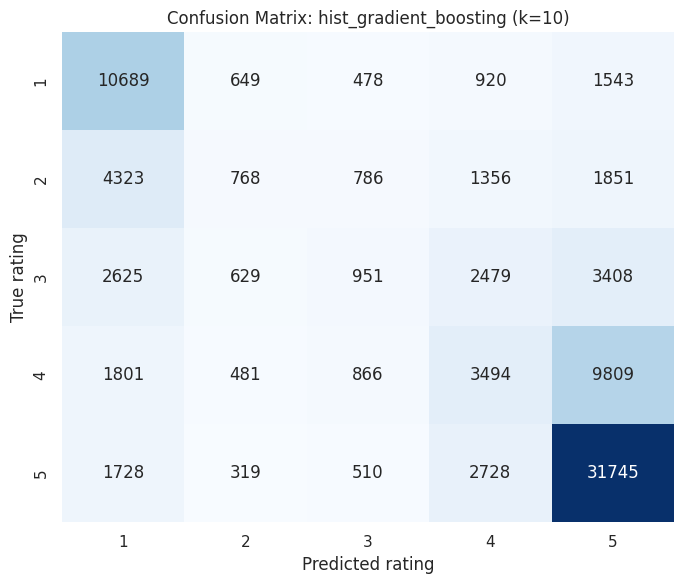

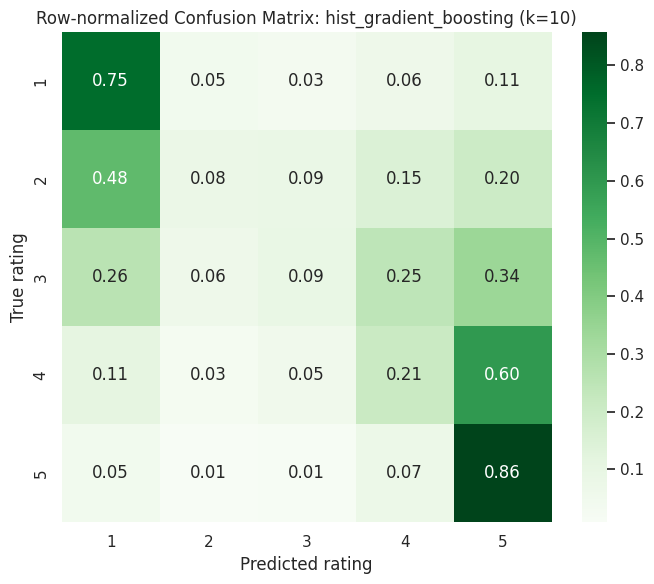

In [8]:
labels = [1, 2, 3, 4, 5]
cm = confusion_matrix(y_test, y_pred, labels=labels)

row_totals = cm.sum(axis=1)
diag = np.diag(cm)
per_rating_accuracy = np.divide(diag, row_totals, out=np.zeros_like(diag, dtype=float), where=row_totals != 0)

per_rating_df = pd.DataFrame({
    'true_rating': labels,
    'support': row_totals,
    'correct_predictions': diag,
    'accuracy_when_true': per_rating_accuracy,
})

print('Per-rating accuracy (conditioned on true class):')
display(per_rating_df)

print('Classification report:')
print(classification_report(y_test, y_pred, labels=labels, digits=4))

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix: {best_model_name} (k={best_k})')
plt.xlabel('Predicted rating')
plt.ylabel('True rating')
plt.tight_layout()
plt.show()

cm_norm = cm / np.clip(row_totals[:, None], 1, None)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title(f'Row-normalized Confusion Matrix: {best_model_name} (k={best_k})')
plt.xlabel('Predicted rating')
plt.ylabel('True rating')
plt.tight_layout()
plt.show()


## Interpretable language and topic takeaways

The goal of this section is not to claim causality. It gives a small set of descriptive patterns from the training split only:
- which frequent rating tags tend to appear with higher or lower clarity ratings
- which NMF topics have higher or lower average observed ratings
- a short plain-English summary of what the model seems to be picking up


In [9]:
# Tag-level descriptive patterns
min_tag_support = max(75, int(0.02 * len(df_train)))
tag_rows = []
for col in tag_cols:
    support = int(df_train[col].sum())
    if support < min_tag_support:
        continue
    present_mean = df_train.loc[df_train[col] == 1, 'clarityRating'].mean()
    absent_mean = df_train.loc[df_train[col] == 0, 'clarityRating'].mean()
    tag_rows.append({
        'tag': col.replace('tag_', ''),
        'support': support,
        'share_of_train': support / len(df_train),
        'mean_rating_when_present': present_mean,
        'rating_lift_vs_absent': present_mean - absent_mean,
    })

tag_summary = pd.DataFrame(tag_rows).sort_values(
    ['rating_lift_vs_absent', 'support'], ascending=[False, False]
).reset_index(drop=True)

top_positive_tags = tag_summary.head(5).copy()
top_negative_tags = tag_summary.tail(5).sort_values('rating_lift_vs_absent').copy()

print('Frequent tags associated with higher observed clarity ratings:')
display(top_positive_tags[['tag', 'support', 'mean_rating_when_present', 'rating_lift_vs_absent']])
print('Frequent tags associated with lower observed clarity ratings:')
display(top_negative_tags[['tag', 'support', 'mean_rating_when_present', 'rating_lift_vs_absent']])

# Topic-level descriptive patterns from the fitted NMF on the training split
x_train_tfidf = vectorizer.transform(train_comments)
W_train = nmf.transform(x_train_tfidf)
H = nmf.components_
feature_names = np.array(vectorizer.get_feature_names_out())
dominant_topic = W_train.argmax(axis=1)
dominant_strength = W_train.max(axis=1)

topic_rows = []
for topic_id in range(nmf.n_components):
    mask = dominant_topic == topic_id
    support = int(mask.sum())
    top_words = feature_names[np.argsort(H[topic_id])[::-1][:8]].tolist()
    topic_rows.append({
        'topic': topic_id,
        'support': support,
        'mean_rating': float(y_train[mask].mean()) if support else np.nan,
        'top_words': ', '.join(top_words),
        'example_strength_mean': float(dominant_strength[mask].mean()) if support else np.nan,
    })

topic_summary = pd.DataFrame(topic_rows).sort_values(['mean_rating', 'support'], ascending=[False, False]).reset_index(drop=True)
print('Topics ranked by average observed clarity rating:')
display(topic_summary[['topic', 'support', 'mean_rating', 'top_words']])


Frequent tags associated with higher observed clarity ratings:


,tag,support,mean_rating_when_present,rating_lift_vs_absent
0,amazing_lectures,34826,4.851634,1.380309
1,inspirational,16826,4.839237,1.297177
2,gives_good_feedback,18973,4.739419,1.199890
3,caring,36090,4.682599,1.198269
4,respected,22723,4.712450,1.184081


Frequent tags associated with lower observed clarity ratings:


,tag,support,mean_rating_when_present,rating_lift_vs_absent
16,tough_grader,26149,1.927416,-1.800358
15,test_heavy,25423,2.565984,-1.111034
14,lots_of_homework,20178,2.691942,-0.961222
13,graded_by_few_things,21748,2.970572,-0.669563
12,lecture_heavy,24555,3.113989,-0.521407


Topics ranked by average observed clarity rating:


,topic,support,mean_rating,top_words
0,7,23253,4.593601,"best, best professor, professor, professors, b..."
1,9,23783,4.522558,"great, great professor, professor, great teach..."
2,5,32433,4.352943,"interesting, easy, class, recommend, fun, high..."
3,1,31170,4.086718,"students, cares, cares students, really cares,..."
4,3,22825,3.936342,"office, hours, office hours, helpful, helpful ..."
5,6,23289,3.797243,"good, teacher, good teacher, good professor, r..."
6,2,24937,3.646188,"nice, guy, nice guy, really, really nice, funn..."
7,4,53520,3.531895,"final, midterm, midterm final, grade, quizzes,..."
8,0,57111,3.360193,"tests, lecture, lectures, exams, hard, questio..."
9,8,78700,2.578539,"class, don, like, just, time, know, teaching, ..."


## Small set of takeaways

After running the previous cell, summarize the strongest patterns in plain language here. Keep them descriptive, not causal. For example:

- Among the frequent tags, the tags near the top of the positive table are associated with higher average clarity ratings, while the tags near the top of the negative table are associated with lower average clarity ratings.
- The highest-rated NMF topics tend to contain words that describe organized explanations, helpful structure, or clear instruction, while the lowest-rated topics tend to contain words that signal confusion, difficulty following lectures, or weak communication.
- These are correlations from the training split, not causal claims about what makes a professor clear.
